In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import (AnnotationBbox, OffsetImage)

data_twist = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07] # Values of m=\varphi/z

# Read data
steps = [[] for _ in range(len(data_twist))]
enes = [[] for _ in range(len(data_twist))]
for i, data in enumerate(data_twist):
    steps[i], enes[i] = np.loadtxt(f"results-2309/potential_{data}.xvg",comments=["@","#"],unpack=True)

The twisting is based upon:
$$
\psi = \tan^-1(\frac{r\varphi}{z}) = \tan^-1(rm)
$$
Where $m$ is the rate of change as we go up in $z$, how the azimuthal angle changes. So, with this and being the simplest one to implement, I did the following tranformation;
$$
\frac{\varphi}{z} = 0 \rightarrow \varphi' = \varphi_0 + mz
$$
As $varphi_0$ is constant, then we have that the tilt depends fully on the slope we plugged in. This obviously then gives the form of the tilt with respect of the radius, as we select a constant slope.

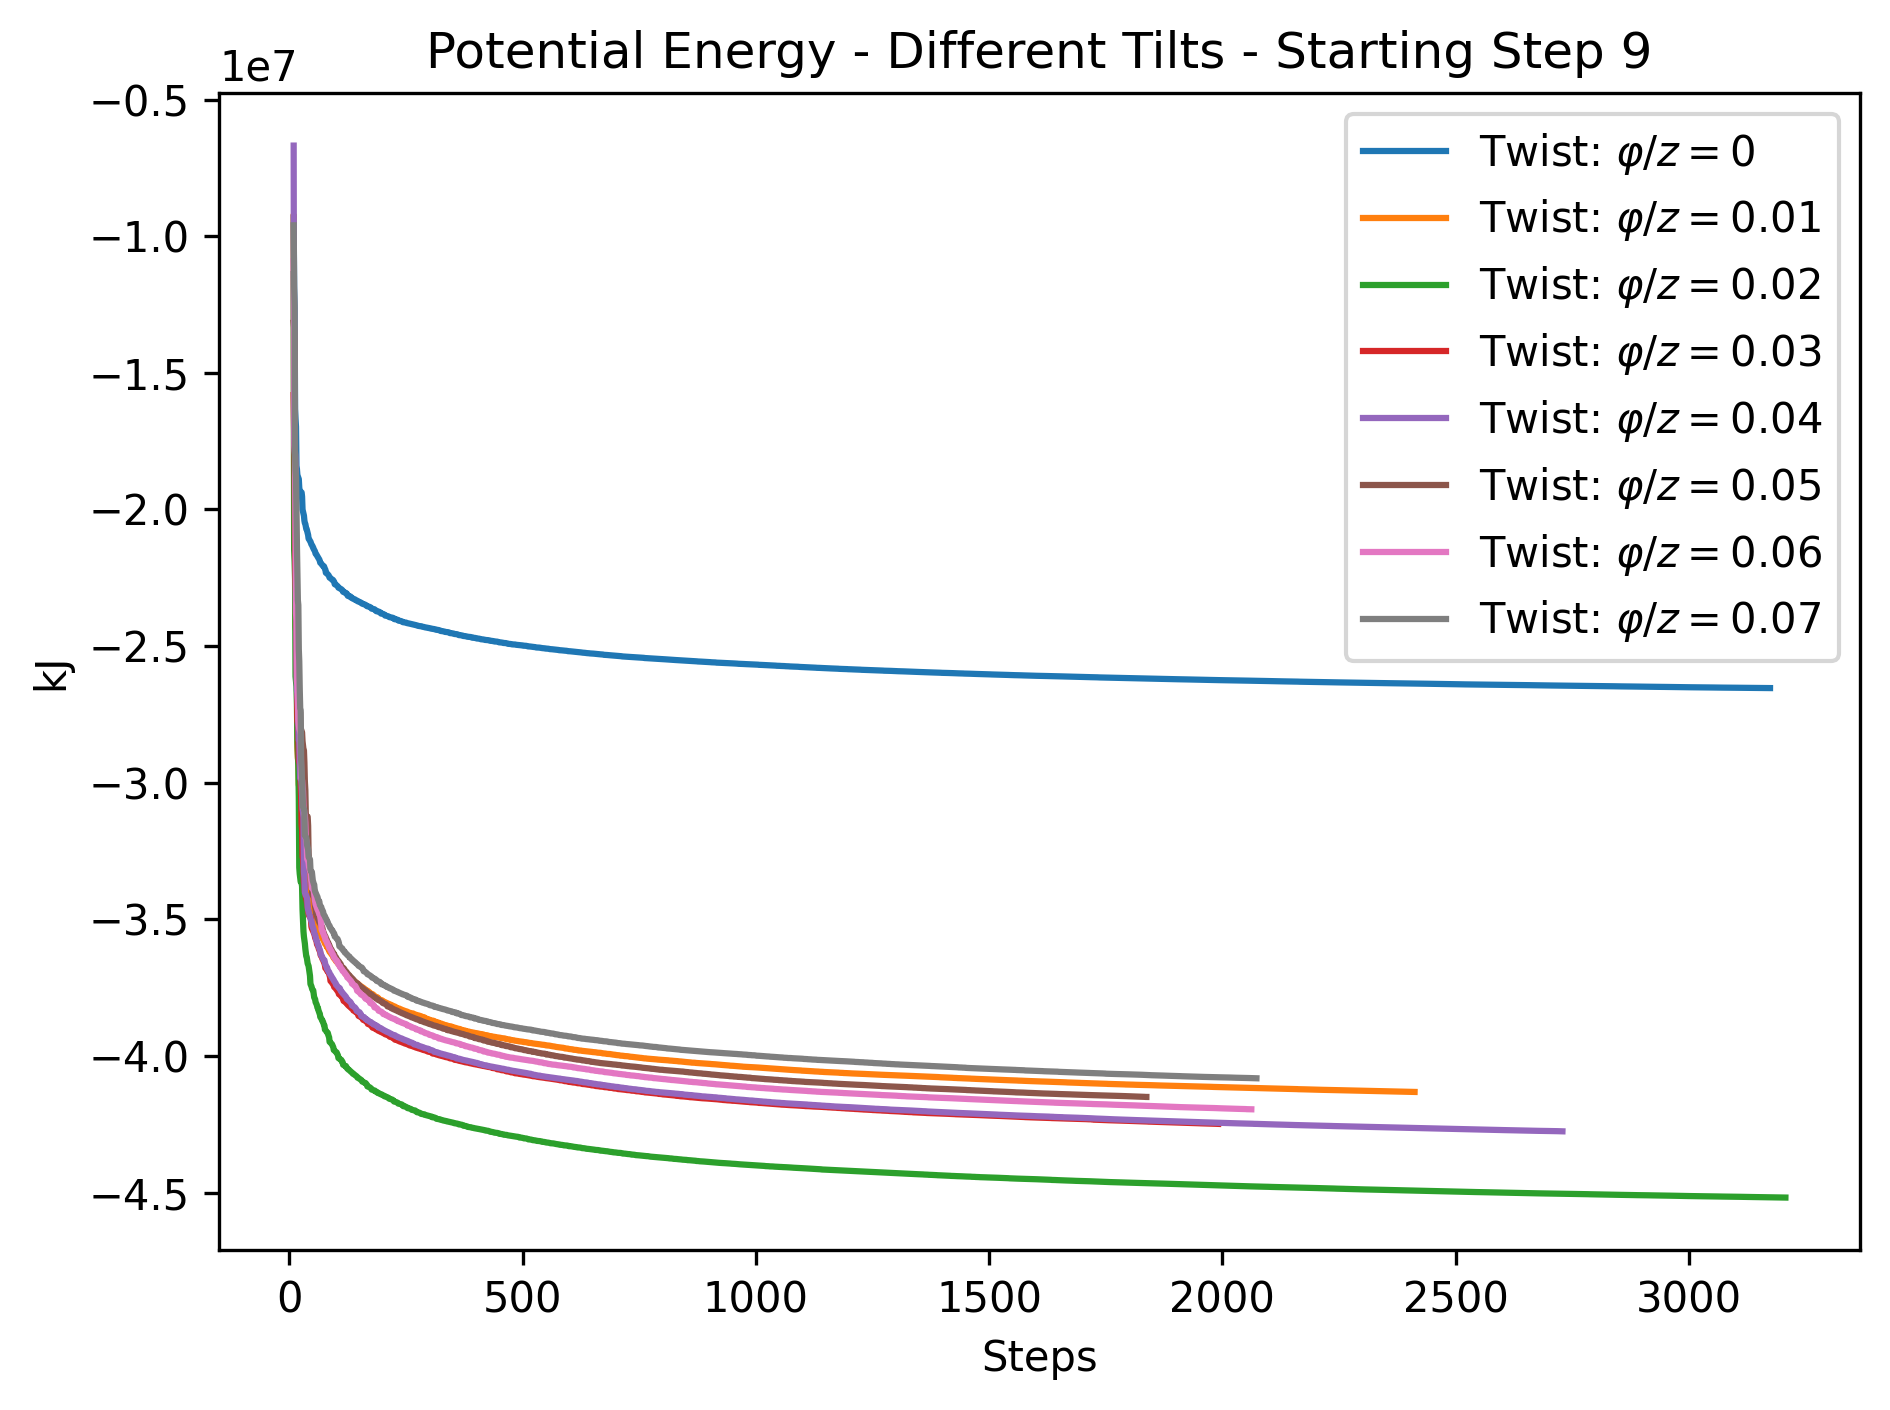

In [40]:
# Plot the data to compare
start_step = 9

plt.figure(dpi=300)

for i, data in enumerate(data_twist):
    offset = -enes[i].min() + 1e-6   # +epsilon to avoid log(0)
    ene_plot = (enes[i][start_step:-1] + offset)
    ene_plot = np.abs(enes[i][start_step:-1])
    #plt.semilogy(steps[i][start_step:-1], ene_plot, label=rf'Twist: $\varphi/z = {data}$')
    plt.plot(steps[i][start_step:-1], enes[i][start_step:-1], label=rf'Twist: $\varphi/z = {data}$')

plt.xlabel('Steps')
plt.ylabel('kJ')
plt.title(f'Potential Energy - Different Tilts - Starting Step {start_step}')
plt.legend()

plt.tight_layout()
plt.show()

This results where gathered using the **steepest descent method**.

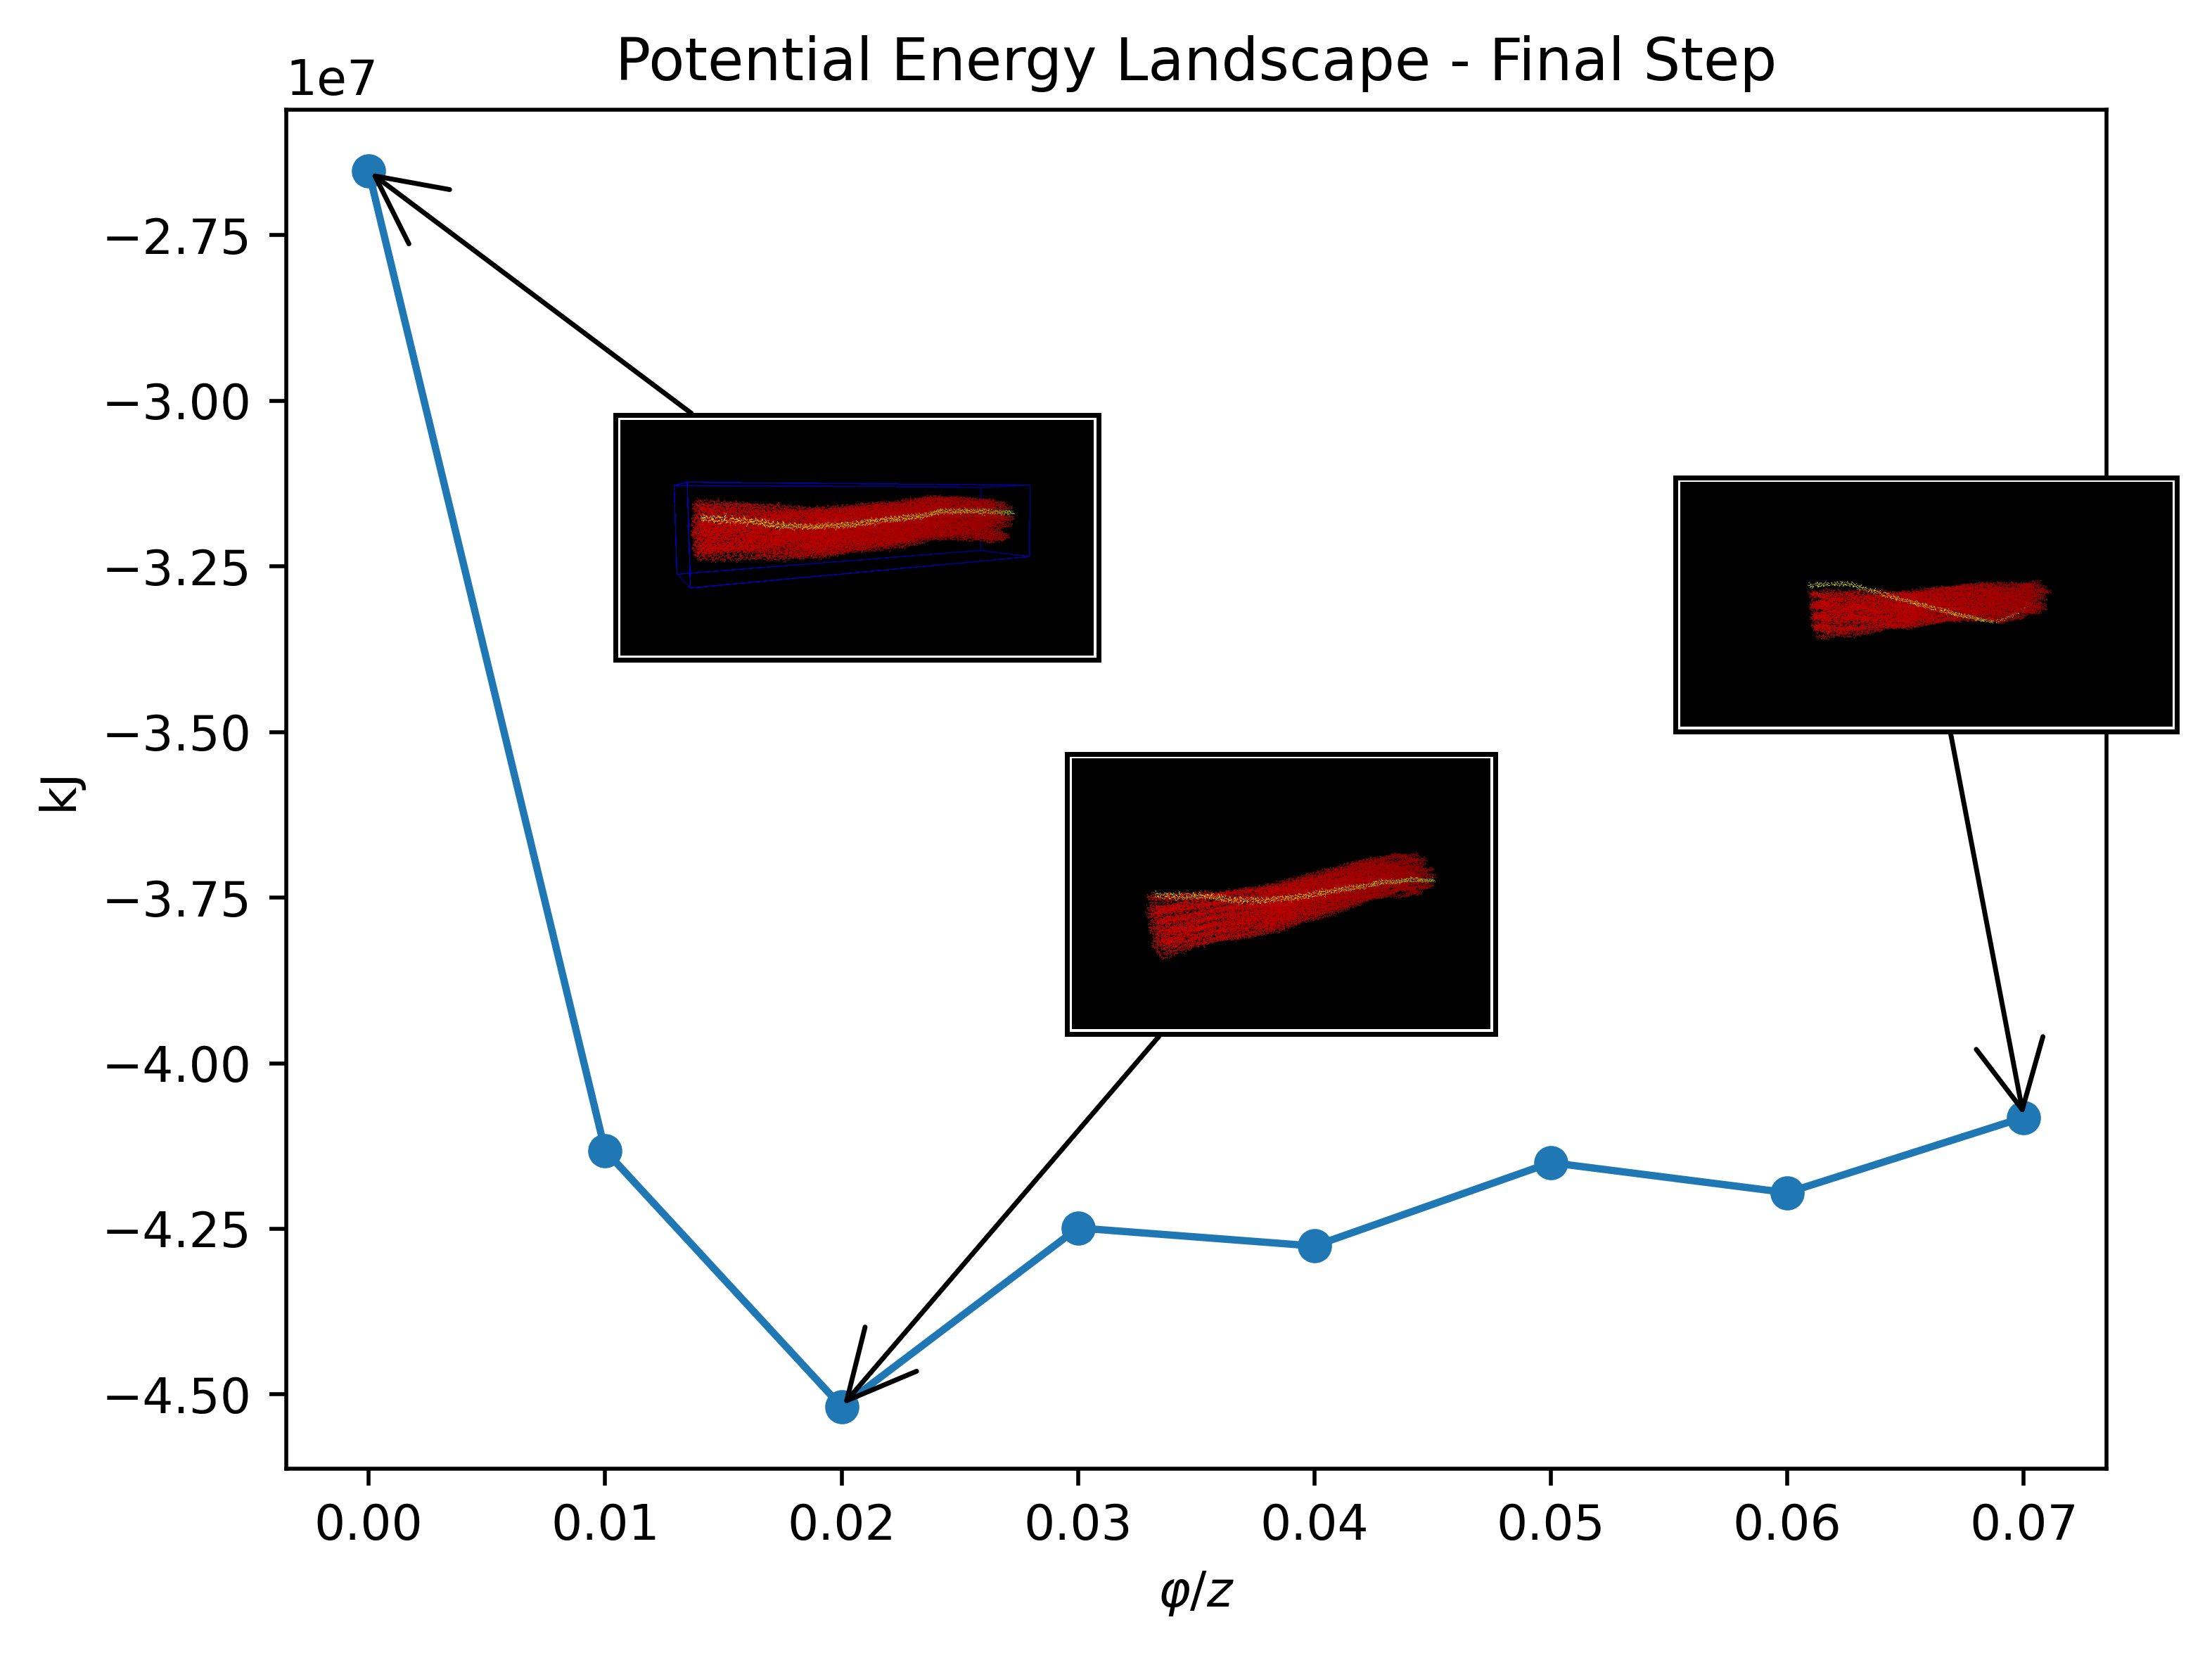

In [3]:
# Plot final energy against twist
fig, ax = plt.subplots(dpi=500)

final_enes = [enes[i][-1] for i in range(len(data_twist))]

plt.plot(data_twist, final_enes)
plt.scatter(data_twist, final_enes)

# Add configs
# --- Twist 0 ---
arr_img = plt.imread("figures/twist0.png")
im = OffsetImage(arr_img, zoom=0.07)
im.image.axes = ax

xy = [data_twist[0], enes[0][-1]]
ab = AnnotationBbox(im, xy,
                    xybox=(100., -75.),
                    xycoords='data',
                    boxcoords="offset points",
                    pad=0.1,
                    arrowprops=dict(
                        arrowstyle="->,head_length=0.2,head_width=0.1",
                        shrinkA=0.5,
                        shrinkB=0.5
                    ))

ax.add_artist(ab)

# --- Twist 0.02 ---
arr_img = plt.imread("figures/twist0.02.png")
im = OffsetImage(arr_img, zoom=0.05)
im.image.axes = ax

xy = [data_twist[2], enes[2][-1]]
ab = AnnotationBbox(im, xy,
                    xybox=(90., 105.),
                    xycoords='data',
                    boxcoords="offset points",
                    pad=0.1,
                    arrowprops=dict(
                        arrowstyle="->,head_length=0.2,head_width=0.1",
                        shrinkA=0.5,
                        shrinkB=0.5
                    ))

ax.add_artist(ab)

# --- Twist 0.02 ---
arr_img = plt.imread("figures/twist0.07.png")
im = OffsetImage(arr_img, zoom=0.05)
im.image.axes = ax

xy = [data_twist[-1], enes[-1][-1]]
ab = AnnotationBbox(im, xy,
                    xybox=(-20, 105.),
                    xycoords='data',
                    boxcoords="offset points",
                    pad=0.1,
                    arrowprops=dict(
                        arrowstyle="->,head_length=0.2,head_width=0.1",
                        shrinkA=0.5,
                        shrinkB=0.5
                    ))

ax.add_artist(ab)

plt.xlabel(r'$\varphi/z$')
plt.ylabel('kJ')
plt.title('Potential Energy Landscape - Final Step')

plt.tight_layout()
plt.show()

#plt.savefig('plotimgs.png')

Evolution of the landscape

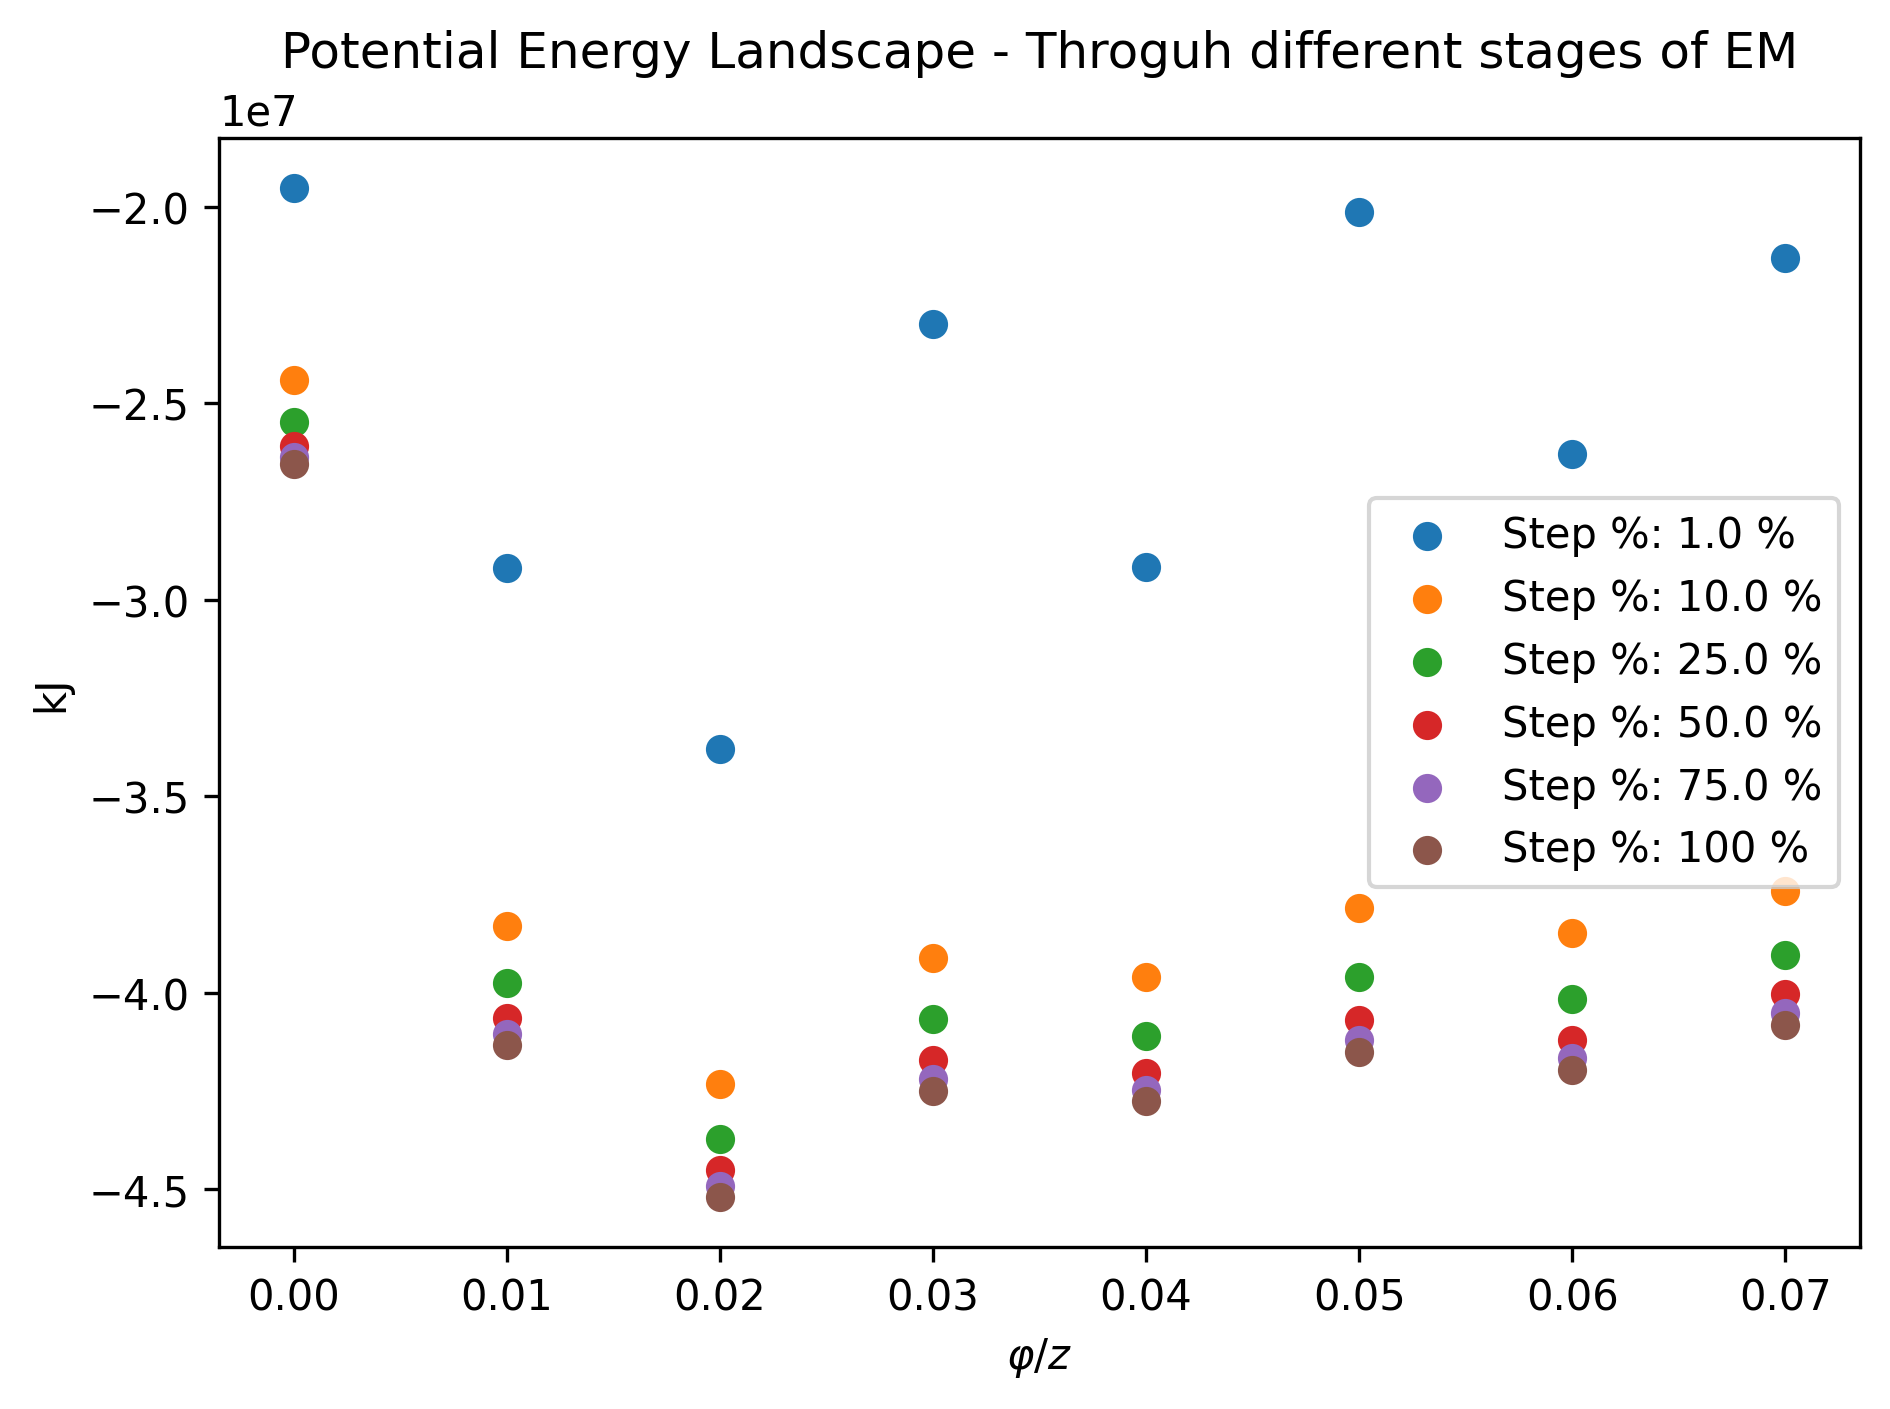

In [4]:
perc = [0.01, 0.1, 0.25, 0.5, 0.75, 1]
plt.figure(dpi=300)

for percentage in perc:
    if percentage == 0:
        energies = [enes[i][0] for i in range(len(data_twist))]
    else:
        energies = [enes[i][int(percentage * len(steps[i])) - 1] for i in range(len(data_twist))]
    plt.scatter(data_twist, energies, label = f'Step %: {percentage*100} %')

plt.xlabel(r'$\varphi/z$')
plt.ylabel('kJ')
plt.title('Potential Energy Landscape - Throguh different stages of EM')

plt.legend()
plt.tight_layout()
plt.show()